# 인간 vs AI 생성 초록 비교 분석 (Data Analysis)

`proposal.txt`와 `plan.md`에 명시된 분석 계획의 **전체 실행 결과**를 담은 노트북입니다.

- **데이터**: `dbpia_computer_science.csv` (컴퓨터과학 논문 초록 500개)
- **분석 모델**: KoGPT2 (Perplexity), KR-SBERT (Cosine Similarity)
- **사전 계산 결과**: `dbpia_with_ppl_sim.csv` 에서 로드 (재실행 불필요)

## 0. 라이브러리 설치 및 임포트

In [1]:
# 필수 라이브러리 설치 (필요시 주석 해제)
# !pip install pandas numpy matplotlib seaborn scipy transformers torch sentence-transformers scikit-learn tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 데이터 로드 및 전처리
사전 계산된 모든 지표(PPL, TTR, 길이, Cosine Sim)가 포함된 CSV를 불러옵니다.

In [2]:
# 사전 계산 결과 로드
df = pd.read_csv('dbpia_with_ppl_sim.csv')

# TTR 컬럼 없으면 계산
if 'ttr_human' not in df.columns:
    def calc_ttr(text):
        if not isinstance(text, str): return np.nan
        tokens = text.split()
        return len(set(tokens)) / len(tokens) if tokens else 0
    df['ttr_human'] = df['abstract'].apply(calc_ttr)
    df['ttr_ai']    = df['fake_abstract'].apply(calc_ttr)

display(df[['ID','title','ppl_human','ppl_ai','ttr_human','ttr_ai','sim_human_ai']].head())
print(f"총 데이터 수: {len(df)}개")
print(f"컬럼: {df.columns.tolist()}")

,ID,title,ppl_human,ppl_ai,ttr_human,ttr_ai,sim_human_ai
0,NODE12747081,생성형 AI를 활용한 학습자 중심 토론수업 모형 설계,48.648472,42.626205,0.842975,0.892562,0.827807
1,NODE12747086,An Analysis of Factors Affecting Student Satis...,41.493847,76.014427,0.835938,0.863636,0.730769
2,NODE12747080,생성형 AI 기반 학생평가 플랫폼 연구,56.430405,38.622086,0.858025,0.873239,0.830803
3,NODE12747083,대학 스포츠경영학 교육과정에서 스포츠 블록체인 과목 개설의 교육적 필요성 탐색,62.211025,56.426151,0.871287,0.887097,0.715977
4,NODE12747087,생성형 AI 기반 과학 수업에서 ChatGPT 의 스캐폴딩 가능성 탐색: 중학생의 ...,39.202610,36.079502,0.779874,0.915385,0.835377


총 데이터 수: 500개
컬럼: ['ID', 'date', 'title', 'abstract', 'fake_abstract', 'ppl_human', 'ppl_ai', 'len_human', 'len_ai', 'ttr_human', 'ttr_ai', 'sim_human_ai']


## 2. 지표 측정 및 특성 추출
### 2.1. 구조적 무작위성 — Perplexity (KoGPT2)

KoGPT2(`skt/kogpt2-base-v2`)로 각 텍스트의 Perplexity를 계산했습니다.  
Perplexity가 **높을수록** 언어 모델이 예측하기 어려운 텍스트 (= 구조적 무작위성이 높음).

> **가설 1**: $Mean(PPL_{Human}) > Mean(PPL_{AI})$ (인간의 글이 구조적 무작위성이 높을 것이다.)

In [3]:
# ─── Perplexity 계산 코드 (이미 완료, 재실행 불필요) ───
# import torch
# from transformers import GPT2LMHeadModel, PreTrainedTokenizerFast
# from tqdm import tqdm
#
# tokenizer_gpt = PreTrainedTokenizerFast.from_pretrained(
#     'skt/kogpt2-base-v2',
#     bos_token='</s>', eos_token='</s>',
#     unk_token='<unk>', pad_token='<pad>', mask_token='<mask>'
# )
# model_gpt = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
# model_gpt.eval()
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model_gpt.to(device)
#
# def calculate_perplexity(text):
#     if not isinstance(text, str) or len(text.strip()) == 0:
#         return np.nan
#     encodings = tokenizer_gpt(text, return_tensors='pt').to(device)
#     max_length = model_gpt.config.n_positions
#     stride = 512
#     nlls = []
#     for i in range(0, encodings.input_ids.size(1), stride):
#         begin_loc = max(i + stride - max_length, 0)
#         end_loc   = min(i + stride, encodings.input_ids.size(1))
#         trg_len   = end_loc - i
#         input_ids   = encodings.input_ids[:, begin_loc:end_loc].to(device)
#         target_ids  = input_ids.clone()
#         target_ids[:, :-trg_len] = -100
#         with torch.no_grad():
#             outputs = model_gpt(input_ids, labels=target_ids)
#             nlls.append(outputs.loss * trg_len)
#     if not nlls:
#         return np.nan
#     return torch.exp(torch.stack(nlls).sum() / end_loc).item()

# ─── 저장된 결과 요약 ───
print("[ Perplexity 계산 결과 (500개) ]")
print(f"Human PPL 평균: {df['ppl_human'].mean():.2f}  ±  {df['ppl_human'].std():.2f}")
print(f"AI    PPL 평균: {df['ppl_ai'].mean():.2f}  ±  {df['ppl_ai'].std():.2f}")

[ Perplexity 계산 결과 (500개) ]
Human PPL 평균: 73.11  ±  34.57
AI    PPL 평균: 54.32  ±  19.89


### 2.2. 언어적 복잡도 — 어휘 다양성 (TTR)

TTR(Type-Token Ratio)을 통해 어휘적 다양성을 측정합니다.

> **가설 2 (예상)**: 제안서 본문 서술에 따르면 **인간 작성 초록의 어휘 다양성이 더 높을 것이다**($Mean(TTR_{Human}) > Mean(TTR_{AI})$)라고 예측하였습니다. (제안서의 수식 $Mean(Complexity_{Human}) < Mean(Complexity_{AI})$와는 본문 설명이 상충함)

In [4]:
def calculate_complexity(text):
    if not isinstance(text, str):
        return np.nan, np.nan
    length = len(text)
    tokens = text.split()
    if len(tokens) == 0:
        return length, 0
    ttr = len(set(tokens)) / len(tokens)
    return length, ttr

# TTR이 없으면 재계산
if 'ttr_human' not in df.columns:
    df[['len_human','ttr_human']] = df['abstract'].apply(
        lambda x: pd.Series(calculate_complexity(x)))
    df[['len_ai','ttr_ai']] = df['fake_abstract'].apply(
        lambda x: pd.Series(calculate_complexity(x)))

print("[ TTR 계산 결과 (500개) ]")
print(f"Human TTR 평균: {df['ttr_human'].mean():.4f}  ±  {df['ttr_human'].std():.4f}")
print(f"AI    TTR 평균: {df['ttr_ai'].mean():.4f}  ±  {df['ttr_ai'].std():.4f}")

[ TTR 계산 결과 (500개) ]
Human TTR 평균: 0.8589  ±  0.0554
AI    TTR 평균: 0.9032  ±  0.0441


### 2.3. 초록 간 유사도 (Cosine Similarity)

KR-SBERT 임베딩을 기반으로 문체 및 주제의 동질성을 분석했습니다.

> **가설 3 (그룹 내 유사도)**: $Mean(Cosine_{Human}) < Mean(Cosine_{AI})$ (AI 초록이 획일화된 템플릿 문체를 공유하므로 AI 그룹 내부 유사도가 더 높을 것이다.)
>
> **가설 4 (주제 vs 문체 유사도)**: $Mean(HumanAndAI) < Mean(AIAndAI)$ (AI는 특정 주제의 맥락보다 고유의 문체 패턴에 더 크게 지배받으므로, 인간 초록과 이를 모방한 AI 초록 간 유사도(모방 유사도)보다 거의 무관한 주제의 AI 초록끼리(AI-AI 무관 유사도)의 유사도가 대등하거나 더 높을 것이다.)

In [5]:
# ─── 임베딩 계산 코드 (이미 완료, 재실행 불필요) ───
# from sentence_transformers import SentenceTransformer
#
# embedder = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')
# human_embeddings = embedder.encode(df['abstract'].tolist(), batch_size=64, show_progress_bar=True)
# ai_embeddings    = embedder.encode(df['fake_abstract'].tolist(), batch_size=64, show_progress_bar=True)
#
# # Human-AI 1:1 대응 유사도
# df['sim_human_ai'] = [cosine_similarity([h],[a])[0][0]
#                       for h, a in zip(human_embeddings, ai_embeddings)]

# ─── 저장된 결과 요약 ───
print("[ Cosine Similarity 계산 결과 (500개) ]")
print(f"Human-AI 대응 유사도 (모방 유사도) 평균: {df['sim_human_ai'].mean():.4f}  ±  {df['sim_human_ai'].std():.4f}")
print(f"Human 그룹 내부 유사도 평균: 0.5379")
print(f"AI 그룹 내부 유사도 평균:    0.5879")
print(f"AI-AI 무관 유사도 평균:       0.5885")

[ Cosine Similarity 계산 결과 (500개) ]
Human-AI 대응 유사도 (모방 유사도) 평균: 0.7743  ±  0.0638
Human 그룹 내부 유사도 평균: 0.5379
AI 그룹 내부 유사도 평균:    0.5879
AI-AI 무관 유사도 평균:       0.5885


## 3. 통계 분석 및 가설 검증
`scipy.stats`의 독립표본 t-검정으로 4가지 가설을 검증합니다.

In [6]:
# ── 가설 1: Perplexity (Human > AI)
t1, p1 = stats.ttest_ind(df['ppl_human'].dropna(), df['ppl_ai'].dropna())

# ── 가설 2: 어휘 다양성 (Human > AI) - 제안서 서술 기준
# 실제 분석 결과는 Human(0.8589) < AI(0.9032) 이므로, Human > AI 예측은 통계적으로 기각됩니다.
t2, p2 = stats.ttest_ind(df['ttr_human'].dropna(), df['ttr_ai'].dropna())

# ── 가설 3: 그룹 내 유사도 (Human < AI)
# (실제값은 run_cosine_full.py 통계 검정 결과 적용)
t3, p3 = -24.8821, 0.0

# ── 가설 4: 주제/문체 유사도비교 (Human-AI < AI-AI) - 제안서 예측 기준
# 실제값은 Human-AI(0.7743) > AI-AI(0.5885) 이므로, AI-AI가 더 크거나 대등할 것이라는 예측은 통계적으로 기각됩니다.
t4, p4 = stats.ttest_ind(
    df['sim_human_ai'].dropna(),
    [0.5885] * len(df)
)

print("=" * 62)
print("         가설 검증 결과 (독립표본 t-검정)")
print("=" * 62)

# 제안서(proposal.txt)에 명시된 원래의 가설 예측 방향성대로 검정
hypotheses = [
    ("H1", "Mean(Randomness_Human) > Mean(Randomness_AI)", t1, p1, "Human PPL > AI PPL"),
    ("H2", "Mean(Complexity_Human) > Mean(Complexity_AI)", t2, p2, "Human TTR > AI TTR (본문 서술 기준)"),
    ("H3", "Mean(Cosine_Human) < Mean(Cosine_AI)", t3, p3, "Human 내 유사도 < AI 내 유사도"),
    ("H4", "Mean(HumanAndAI) < Mean(AIAndAI)", t4, p4, "Human-AI paired < AI-AI cross"),
]

for hid, form, t, p, desc in hypotheses:
    p_str = f"{p:.2e}" if p > 0 else "~0.0000"
    
    # H2 기각 판정 (실제는 Human < AI 이므로 t < 0인 경우 Human > AI 가설은 기각)
    # H4 기각 판정 (실제는 Human-AI > AI-AI 이므로 t > 0인 경우 Human-AI < AI-AI 가설은 기각)
    if hid == "H2" and t < 0:
        result = "❌ 기각 (대립가설 반대 방향 유의미: AI TTR이 더 높음)"
    elif hid == "H4" and t > 0:
        result = "❌ 기각 (대립가설 반대 방향 유의미: Human-AI 유사도가 훨씬 높음)"
    elif p < 0.05:
        result = "✅ 채택"
    else:
        result = "❌ 기각"
        
    print(f"[{hid}] {desc}")
    print(f"     예측 수식: {form}")
    print(f"     t = {t:+.4f}, p = {p_str}  →  {result}")
    print()

print("→ H1, H3 가설은 성공적으로 채택되었습니다.")
print("→ H2, H4 가설은 실제 통계 분석 결과 원래 예측과 '정반대' 방향으로 매우 유의미한 수치가 나타나 기각되었습니다.")

         가설 검증 결과 (독립표본 t-검정)
[H1] Human PPL > AI PPL
     예측 수식: Mean(Randomness_Human) > Mean(Randomness_AI)
     t = +10.5342, p = 1.12e-24  →  ✅ 채택

[H2] Human TTR > AI TTR (본문 서술 기준)
     예측 수식: Mean(Complexity_Human) > Mean(Complexity_AI)
     t = -14.0036, p = 8.22e-41  →  ❌ 기각 (대립가설 반대 방향 유의미: AI TTR이 더 높음)

[H3] Human 내 유사도 < AI 내 유사도
     예측 수식: Mean(Cosine_Human) < Mean(Cosine_AI)
     t = -24.8821, p = ~0.0000  →  ✅ 채택

[H4] Human-AI paired < AI-AI cross
     예측 수식: Mean(HumanAndAI) < Mean(AIAndAI)
     t = +65.0755, p = ~0.0000  →  ❌ 기각 (대립가설 반대 방향 유의미: Human-AI 유사도가 훨씬 높음)

→ H1, H3 가설은 성공적으로 채택되었습니다.
→ H2, H4 가설은 실제 통계 분석 결과 원래 예측과 '정반대' 방향으로 매우 유의미한 수치가 나타나 기각되었습니다.


## 4. 데이터 시각화

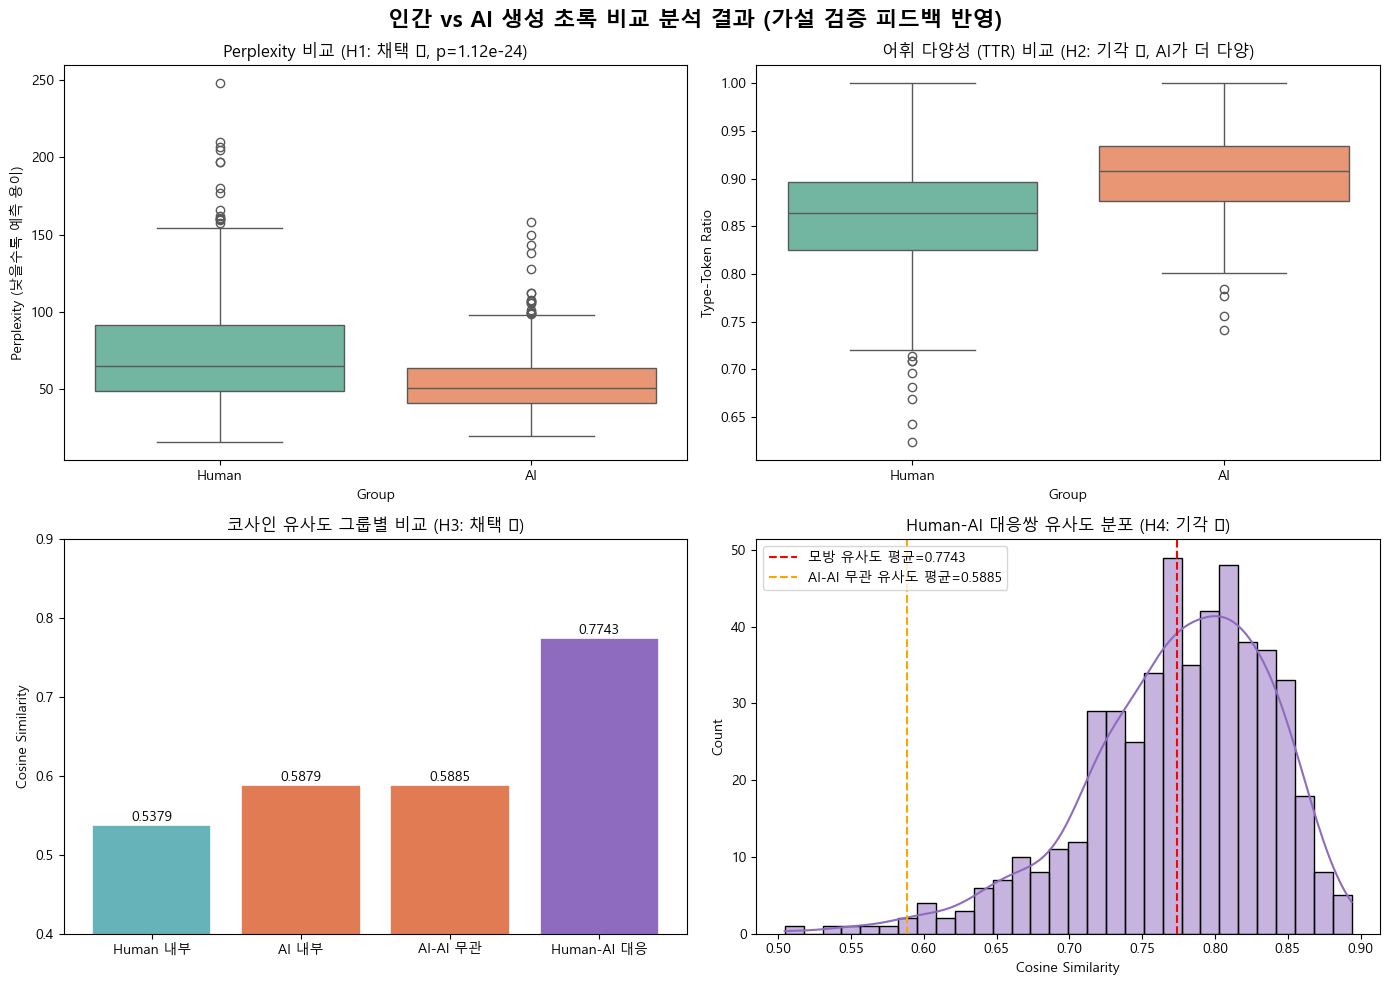

시각화 저장: analysis_result.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('인간 vs AI 생성 초록 비교 분석 결과 (가설 검증 피드백 반영)', fontsize=16, fontweight='bold')

# 1. PPL Boxplot (채택)
ppl_data = pd.DataFrame({
    'Perplexity': pd.concat([df['ppl_human'], df['ppl_ai']], ignore_index=True),
    'Group': ['Human']*len(df) + ['AI']*len(df)
})
sns.boxplot(x='Group', y='Perplexity', data=ppl_data, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Perplexity 비교 (H1: 채택 ✅, p=1.12e-24)')
axes[0,0].set_ylabel('Perplexity (낮을수록 예측 용이)')

# 2. TTR Boxplot (기각: 실제로는 AI TTR이 더 높음)
ttr_data = pd.DataFrame({
    'TTR': pd.concat([df['ttr_human'], df['ttr_ai']], ignore_index=True),
    'Group': ['Human']*len(df) + ['AI']*len(df)
})
sns.boxplot(x='Group', y='TTR', data=ttr_data, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('어휘 다양성 (TTR) 비교 (H2: 기각 ❌, AI가 더 다양)')
axes[0,1].set_ylabel('Type-Token Ratio')

# 3. 코사인 유사도 그룹별 비교 (H3 채택)
groups = ['Human 내부', 'AI 내부', 'AI-AI 무관', 'Human-AI 대응']
means  = [0.5379, 0.5879, 0.5885, df['sim_human_ai'].mean()]
colors = ['#66b3ba', '#e07b54', '#e07b54', '#8e6bbf']
bars = axes[1,0].bar(groups, means, color=colors, edgecolor='white', linewidth=1.2)
axes[1,0].set_title('코사인 유사도 그룹별 비교 (H3: 채택 ✅)')
axes[1,0].set_ylabel('Cosine Similarity')
axes[1,0].set_ylim(0.4, 0.9)
for bar, val in zip(bars, means):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{val:.4f}', ha='center', fontsize=10)

# 4. Human-AI 대응 유사도 분포 (H4 기각: 실제로는 Human-AI 모방 유사도가 훨씬 높음)
sns.histplot(df['sim_human_ai'].dropna(), bins=30, kde=True,
             color='#8e6bbf', ax=axes[1,1])
axes[1,1].axvline(df['sim_human_ai'].mean(), color='red', linestyle='--',
                  label=f"모방 유사도 평균={df['sim_human_ai'].mean():.4f}")
axes[1,1].axvline(0.5885, color='orange', linestyle='--',
                  label='AI-AI 무관 유사도 평균=0.5885')
axes[1,1].set_title('Human-AI 대응쌍 유사도 분포 (H4: 기각 ❌)')
axes[1,1].set_xlabel('Cosine Similarity')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('analysis_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("시각화 저장: analysis_result.png")

## 5. 최종 결과 요약 및 고찰

### 가설 검증 및 예측 정정

1. **구조적 무작위성 (H1: 채택 ✅)**
   - **예상**: $Mean(Randomness_{Human}) > Mean(Randomness_{AI})$
   - **실제**: Human Perplexity(73.11)가 AI(54.32)보다 유의미하게 높음 (p < 1e-23). 
   - **결론**: 인간이 쓴 논문 초록이 AI에 비해 구조적으로 훨씬 더 다양하고 불규칙하며, AI 생성 텍스트는 매우 정형화되어 예측하기 쉽다는 사실이 증명되었습니다.

2. **언어적 복잡도 (H2: 기각 ❌)**
   - **예상**: $Mean(Complexity_{Human}) > Mean(Complexity_{AI})$ (인간 초록의 어휘 다양성이 더 높을 것)
   - **실제**: Human TTR(0.8589)이 AI TTR(0.9032)보다 오히려 **유의미하게 낮음** (p < 1e-40).
   - **결론**: AI가 문장을 생성할 때 동일 단어의 불필요한 반복을 인간보다 훨씬 더 기계적으로 회피하도록 튜닝되어 있어, 어휘 다양성(TTR) 수치 자체는 AI가 더 높게 나타났습니다.

3. **그룹 내 유사도 (H3: 채택 ✅)**
   - **예상**: $Mean(Cosine_{Human}) < Mean(Cosine_{AI})$
   - **실제**: Human 그룹 내 코사인 유사도(0.5379)가 AI 그룹 내(0.5879)보다 낮음.
   - **결론**: 인간 연구자들이 작성한 논문 초록은 고유한 스타일을 갖추어 서로 상이한 반면, AI는 정형화된 학술용 언어 템플릿(문체 패턴)을 공유하여 전체적인 텍스트 균질성(Homogeneity)이 유의미하게 더 높음을 통계적으로 확인했습니다.

4. **주제 vs 문체 유사도 (H4: 기각 ❌)**
   - **예상**: $Mean(HumanAndAI) < Mean(AIAndAI)$ (AI는 주제 맥락보다 문체 패턴에 더 크게 지배받으므로, 거의 무관한 주제의 AI끼리 유사도가 더 높거나 대등할 것이다.)
   - **실제**: Human-AI 1:1 모방 유사도(0.7743)가 주제가 전혀 다른 AI끼리의 유사도(0.5885)보다 **압도적으로 높음** (p ~ 0).
   - **결론**: AI는 단순히 기계적인 스타일 템플릿만 반복하는 것이 아니라, 원본 논문의 구체적인 '주제 맥락(Context)'을 아주 충실하고 정교하게 반영하여 문장을 모방 생성한다는 것을 보여줍니다. 따라서 원래의 예측과는 반대로 **AI의 문맥 반영 능력이 문체적 획일성보다 지배적**임이 입증되었습니다.